<a href="https://colab.research.google.com/github/MiniMaliZ/Sistem-Rekomendasi-Kost/blob/main/04_Certainty%20Factor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistem Rekomendasi Kos — Certainty Factor

**Mata Kuliah:** Sistem Berbasis Pengetahuan  
**Politeknik Negeri Malang — Jurusan Teknologi Informasi**

---

## Konsep Certainty Factor

**Certainty Factor (CF)** adalah metode untuk merepresentasikan tingkat keyakinan pakar terhadap suatu aturan/kesimpulan. CF berbeda dari probabilitas: CF mengukur **seberapa yakin** seorang ahli terhadap suatu aturan.

**Range CF:** −1.0 (pasti TIDAK) hingga +1.0 (pasti YA)

**Rumus dasar:**

$$CF(H, E) = MB(H, E) - MD(H, E)$$

Di mana:
- **MB** (Measure of Belief): Ukuran kepercayaan
- **MD** (Measure of Disbelief): Ukuran ketidakpercayaan

**Kombinasi CF untuk dua aturan paralel:**
$$CF_{combined} = CF_1 + CF_2 \cdot (1 - CF_1) \quad \text{(jika keduanya positif)}$$

**CF pengguna × CF pakar:**
$$CF_{akhir} = CF_{user} \times CF_{expert}$$

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
print('Library siap!')

Library siap!


## Load & Preprocessing Data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mamikos_Jabodetabek_Data.xlsx to Mamikos_Jabodetabek_Data.xlsx


In [ ]:
df_raw = pd.read_excel('Mamikos_Jabodetabek_Data.xlsx')

def parse_price(p):
    cleaned = re.sub(r'[Rp.\s]', '', str(p))
    try: return int(cleaned)
    except: return np.nan

def parse_rating(r):
    if str(r).strip() == 'Not found': return np.nan
    try: return float(r)
    except: return np.nan

def parse_room_size(s):
    m = re.search(r'([\d.]+)\s*[xX]\s*([\d.]+)', str(s))
    return float(m.group(1)) * float(m.group(2)) if m else np.nan

df = df_raw.copy()
df['price_numeric'] = df['price'].apply(parse_price)
df['rating_numeric'] = df['rating'].apply(parse_rating)
df['rating_numeric'] = df['rating_numeric'].fillna(df['rating_numeric'].median())
df['room_size_m2'] = df['room_size'].apply(parse_room_size)
df['room_size_m2'] = df['room_size_m2'].fillna(df['room_size_m2'].median())
df['electricity_included'] = df['is_electricity_included'].apply(lambda x: 1 if 'termasuk' in str(x).lower() else 0)

for col, kw in [('has_ac','AC'),('has_wifi','WiFi'),('has_private_bathroom','K. Mandi Dalam'),
                ('has_parking','Parkir'),('has_cctv','CCTV'),('has_laundry','Laundry'),
                ('has_kitchen','Dapur'),('has_wardrobe','Lemari Baju'),('has_bed','Kasur')]:
    df[col] = df['all_facilities_bs'].apply(lambda x: 1 if kw.lower() in str(x).lower() else 0)

df['total_facilities'] = df[['has_ac','has_wifi','has_private_bathroom','has_parking',
                               'has_cctv','has_laundry','has_kitchen','has_wardrobe','has_bed']].sum(axis=1)

def parse_numeric(val):
    try: return int(float(str(val).replace(',','')))
    except: return 0

df['rating_count_num'] = df['rating_count'].apply(parse_numeric)
df = df.dropna(subset=['price_numeric'])
df = df[df['price_numeric'] > 0].reset_index(drop=True)
print(f'Data preprocessed: {df.shape}')

Data preprocessed: (2485, 32)


## Knowledge Base — CF Rules

Setiap rule memiliki:
- **kondisi**: kriteria yang dievaluasi
- **hipotesis**: kesimpulan yang dihasilkan
- **CF_pakar**: keyakinan pakar terhadap rule ini (−1 hingga +1)
- **CF_user**: seberapa besar pengguna menginginkan kriteria ini

In [ ]:
# ======================================================
# RULE BASE dengan Certainty Factor
# CF_pakar: keyakinan pakar terhadap rule (ditetapkan oleh domain expert)
# ======================================================

CF_RULES = [
    # === RULES POSITIF (mendukung rekomendasi) ===
    {
        'id': 'R01',
        'nama': 'Rating Sangat Baik',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['rating_numeric'] >= 4.5,
        'CF_pakar': 0.9,  # Pakar sangat yakin rating tinggi = direkomendasikan
    },
    {
        'id': 'R02',
        'nama': 'Rating Baik',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: 4.0 <= row['rating_numeric'] < 4.5,
        'CF_pakar': 0.7,
    },
    {
        'id': 'R03',
        'nama': 'Fasilitas Lengkap (≥7 fasilitas)',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['total_facilities'] >= 7,
        'CF_pakar': 0.8,
    },
    {
        'id': 'R04',
        'nama': 'Ada AC',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['has_ac'] == 1,
        'CF_pakar': 0.6,
    },
    {
        'id': 'R05',
        'nama': 'Ada WiFi',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['has_wifi'] == 1,
        'CF_pakar': 0.65,
    },
    {
        'id': 'R06',
        'nama': 'Kamar Mandi Dalam',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['has_private_bathroom'] == 1,
        'CF_pakar': 0.7,
    },
    {
        'id': 'R07',
        'nama': 'Listrik Termasuk',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['electricity_included'] == 1,
        'CF_pakar': 0.55,
    },
    {
        'id': 'R08',
        'nama': 'Ada CCTV (Keamanan)',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['has_cctv'] == 1,
        'CF_pakar': 0.6,
    },
    {
        'id': 'R09',
        'nama': 'Kamar Luas (≥16 m²)',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['room_size_m2'] >= 16,
        'CF_pakar': 0.5,
    },
    {
        'id': 'R10',
        'nama': 'Harga Sangat Mahal (>Rp3.5jt)',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['price_numeric'] > 3_500_000,
        'CF_pakar': 0.3,  # Mahal tidak selalu baik
    },

    # === RULES NEGATIF (mengurangi keyakinan) ===
    {
        'id': 'R11',
        'nama': 'Rating Kurang (<3.0)',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['rating_numeric'] < 3.0 and row['rating_numeric'] > 0,
        'CF_pakar': -0.8,  # Sangat tidak direkomendasikan
    },
    {
        'id': 'R12',
        'nama': 'Fasilitas Sangat Minim (<3)',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['total_facilities'] < 3,
        'CF_pakar': -0.5,
    },
    {
        'id': 'R13',
        'nama': 'Tidak Ada Parkir & CCTV',
        'hipotesis': 'Direkomendasikan',
        'kondisi': lambda row: row['has_parking'] == 0 and row['has_cctv'] == 0,
        'CF_pakar': -0.3,
    },
]

positive_rules = [r for r in CF_RULES if r['CF_pakar'] > 0]
negative_rules = [r for r in CF_RULES if r['CF_pakar'] < 0]
print(f'Total rules CF: {len(CF_RULES)}')
print(f'  Rules positif: {len(positive_rules)}')
print(f'  Rules negatif: {len(negative_rules)}')

Total rules CF: 13
  Rules positif: 10
  Rules negatif: 3


## Implementasi Certainty Factor Engine

In [ ]:
def kombinasi_cf(cf1, cf2):
    """
    Kombinasi dua CF menggunakan rumus standar Certainty Factor.

    Kasus:
    - Keduanya positif : CF1 + CF2 × (1 - CF1)
    - Keduanya negatif : CF1 + CF2 × (1 + CF1)
    - Berbeda tanda    : (CF1 + CF2) / (1 - min(|CF1|, |CF2|))
    """
    if cf1 >= 0 and cf2 >= 0:
        return cf1 + cf2 * (1 - cf1)
    elif cf1 < 0 and cf2 < 0:
        return cf1 + cf2 * (1 + cf1)
    else:
        denom = 1 - min(abs(cf1), abs(cf2))
        if denom == 0:
            return 0
        return (cf1 + cf2) / denom


def hitung_cf_kos(row, rules, cf_user=1.0, verbose=False):
    """
    Hitung CF total untuk sebuah kos berdasarkan rules.

    cf_user: keyakinan pengguna terhadap gejala (default 1.0 = pasti)
    CF_akhir = CF_user × CF_pakar
    """
    fired_rules = []
    cf_combined = 0.0
    first = True

    if verbose:
        print(f'Menghitung CF untuk: {row["room_name"]}')

    for rule in rules:
        try:
            kondisi_terpenuhi = rule['kondisi'](row)
        except:
            kondisi_terpenuhi = False

        if kondisi_terpenuhi:
            # CF akhir per rule = CF_user × CF_pakar
            cf_rule = cf_user * rule['CF_pakar']
            fired_rules.append({
                'id': rule['id'],
                'nama': rule['nama'],
                'cf_pakar': rule['CF_pakar'],
                'cf_rule': cf_rule
            })

            if verbose:
                print(f'  [{rule["id"]}] {rule["nama"]} → CF_pakar={rule["CF_pakar"]}, CF_rule={cf_rule:.3f}')

            # Kombinasikan CF
            if first:
                cf_combined = cf_rule
                first = False
            else:
                old_cf = cf_combined
                cf_combined = kombinasi_cf(cf_combined, cf_rule)
                if verbose:
                    print(f'    Kombinasi: CF({old_cf:.3f}, {cf_rule:.3f}) = {cf_combined:.3f}')

    if verbose:
        print(f'  CF TOTAL = {cf_combined:.4f}')
        print()

    return cf_combined, fired_rules


def certainty_factor_engine(df, rules, cf_user=1.0):
    """Jalankan CF untuk seluruh dataset."""
    cf_scores = []
    cf_rules_count = []
    cf_labels = []

    for _, row in df.iterrows():
        cf_total, fired = hitung_cf_kos(row, rules, cf_user)
        cf_scores.append(cf_total)
        cf_rules_count.append(len(fired))

        # Interpretasi CF
        if cf_total >= 0.8:
            label = 'Sangat Direkomendasikan'
        elif cf_total >= 0.6:
            label = 'Direkomendasikan'
        elif cf_total >= 0.4:
            label = 'Cukup Direkomendasikan'
        elif cf_total >= 0.2:
            label = 'Kurang Pasti'
        elif cf_total >= 0:
            label = 'Netral'
        else:
            label = 'Tidak Direkomendasikan'

        cf_labels.append(label)

    return cf_scores, cf_labels, cf_rules_count


print('CF Engine siap!')

CF Engine siap!


### Demo: Perhitungan Manual CF untuk 1 Kos

In [ ]:
# Pilih kos sample dan tampilkan trace CF
kos_sample = df.iloc[5]
print(f'=== DEMO CF DETAIL ===' )
print(f'Kos       : {kos_sample["room_name"]}')
print(f'Region    : {kos_sample["region"]}')
print(f'Harga     : Rp{kos_sample["price_numeric"]:,}')
print(f'Rating    : {kos_sample["rating_numeric"]}')
print(f'Fasilitas : {kos_sample["total_facilities"]} items')
print(f'AC        : {kos_sample["has_ac"]}, WiFi: {kos_sample["has_wifi"]}, KM Dalam: {kos_sample["has_private_bathroom"]}')
print(f'CCTV      : {kos_sample["has_cctv"]}, Listrik Inkl: {kos_sample["electricity_included"]}')
print()

cf_total, fired = hitung_cf_kos(kos_sample, CF_RULES, cf_user=1.0, verbose=True)

print(f'Rules yang aktif: {len(fired)}')
print(f'CF FINAL: {cf_total:.4f}')

=== DEMO CF DETAIL ===
Kos       : Kost 21 Alam Sutera Tipe B Serpong Utara Tangerang Selatan
Region    : Tangerang Selatan
Harga     : Rp2,200,000
Rating    : 4.8
Fasilitas : 7 items
AC        : 1, WiFi: 1, KM Dalam: 0
CCTV      : 0, Listrik Inkl: 1

Menghitung CF untuk: Kost 21 Alam Sutera Tipe B Serpong Utara Tangerang Selatan
  [R01] Rating Sangat Baik → CF_pakar=0.9, CF_rule=0.900
  [R03] Fasilitas Lengkap (≥7 fasilitas) → CF_pakar=0.8, CF_rule=0.800
    Kombinasi: CF(0.900, 0.800) = 0.980
  [R04] Ada AC → CF_pakar=0.6, CF_rule=0.600
    Kombinasi: CF(0.980, 0.600) = 0.992
  [R05] Ada WiFi → CF_pakar=0.65, CF_rule=0.650
    Kombinasi: CF(0.992, 0.650) = 0.997
  [R07] Listrik Termasuk → CF_pakar=0.55, CF_rule=0.550
    Kombinasi: CF(0.997, 0.550) = 0.999
  CF TOTAL = 0.9987

Rules yang aktif: 5
CF FINAL: 0.9987


### Jalankan CF untuk Seluruh Dataset

In [ ]:
print('Menjalankan Certainty Factor Engine...')
cf_scores, cf_labels, cf_rules_count = certainty_factor_engine(df, CF_RULES, cf_user=1.0)

df['cf_score'] = cf_scores
df['cf_label'] = cf_labels
df['cf_rules_matched'] = cf_rules_count

print('Selesai!')
print()
print('=== Distribusi CF Label ===')
print(df['cf_label'].value_counts())
print()
print('=== Statistik CF Score ===')
print(df['cf_score'].describe())

Menjalankan Certainty Factor Engine...
Selesai!

=== Distribusi CF Label ===
cf_label
Sangat Direkomendasikan    2455
Direkomendasikan             25
Tidak Direkomendasikan        2
Kurang Pasti                  2
Cukup Direkomendasikan        1
Name: count, dtype: int64

=== Statistik CF Score ===
count    2485.000000
mean        0.989926
std         0.051875
min        -0.222222
25%         0.994600
50%         0.999546
75%         0.999849
max         0.999947
Name: cf_score, dtype: float64


### Fungsi Rekomendasi dengan CF User-Adjustable

In [ ]:
def rekomendasi_cf(df, cf_rules, preferensi_user, cf_user_global=1.0, top_n=10):
    """
    Rekomendasi kos menggunakan Certainty Factor.

    cf_user_global: keyakinan pengguna terhadap semua preferensinya (0 < CF ≤ 1)
                    1.0 = sangat yakin, 0.5 = tidak terlalu yakin
    """
    df_filtered = df.copy()

    # Filter dasar
    if 'budget_max' in preferensi_user:
        df_filtered = df_filtered[df_filtered['price_numeric'] <= preferensi_user['budget_max']]
    if 'tipe_kos' in preferensi_user:
        df_filtered = df_filtered[df_filtered['tipe_kos'] == preferensi_user['tipe_kos']]
    if 'region' in preferensi_user:
        df_filtered = df_filtered[df_filtered['region'].str.contains(preferensi_user['region'], case=False, na=False)]

    # Bangun rules dinamis berdasarkan preferensi
    user_rules = list(cf_rules)  # copy base rules

    # Tambah rule dinamis dari preferensi user
    if preferensi_user.get('butuh_wifi'):
        user_rules.append({'id': 'U01', 'nama': 'WiFi (User Preference)',
                           'hipotesis': 'Direkomendasikan',
                           'kondisi': lambda r: r['has_wifi'] == 1, 'CF_pakar': 0.7})
    if preferensi_user.get('butuh_ac'):
        user_rules.append({'id': 'U02', 'nama': 'AC (User Preference)',
                           'hipotesis': 'Direkomendasikan',
                           'kondisi': lambda r: r['has_ac'] == 1, 'CF_pakar': 0.7})
    if preferensi_user.get('butuh_laundry'):
        user_rules.append({'id': 'U03', 'nama': 'Laundry (User Preference)',
                           'hipotesis': 'Direkomendasikan',
                           'kondisi': lambda r: r['has_laundry'] == 1, 'CF_pakar': 0.5})

    # Hitung CF dengan bobot user
    hasil = []
    for _, row in df_filtered.iterrows():
        cf_total, fired = hitung_cf_kos(row, user_rules, cf_user=cf_user_global)
        hasil.append({
            'room_name': row['room_name'],
            'region': row['region'],
            'tipe_kos': row['tipe_kos'],
            'price_numeric': row['price_numeric'],
            'rating_numeric': row['rating_numeric'],
            'total_facilities': row['total_facilities'],
            'cf_score': round(cf_total, 4),
            'rules_active': len(fired)
        })

    result_df = pd.DataFrame(hasil)
    result_df['cf_kategori'] = result_df['cf_score'].apply(
        lambda x: 'Sangat Direkomendasikan' if x >= 0.8 else
                  ('Direkomendasikan' if x >= 0.6 else
                   ('Cukup' if x >= 0.4 else 'Kurang'))
    )

    result_df = result_df.sort_values('cf_score', ascending=False)
    return result_df.head(top_n)


# ======================================
# CONTOH 1: Mahasiswi hemat, perlu WiFi
# ======================================
print('=== CF REKOMENDASI 1: Mahasiswi, budget ≤1.8jt, WiFi, di Depok ===')
pref1 = {
    'budget_max': 1_800_000,
    'tipe_kos': 'Kos Putri',
    'region': 'Depok',
    'butuh_wifi': True
}
r1 = rekomendasi_cf(df, CF_RULES, pref1, cf_user_global=0.9, top_n=5)
print(r1.to_string())

=== CF REKOMENDASI 1: Mahasiswi, budget ≤1.8jt, WiFi, di Depok ===
                                     room_name region   tipe_kos  price_numeric  rating_numeric  total_facilities  cf_score  rules_active              cf_kategori
0              Kost 28 Pondoklabu Cinere Depok  Depok  Kos Putri        1350000             4.8                 8    0.9998             9  Sangat Direkomendasikan
2             Kost A21 Pondoklabu Cinere Depok  Depok  Kos Putri        1600000             4.8                 8    0.9998             9  Sangat Direkomendasikan
22               Kost Bambon Tipe 1 Beji Depok  Depok  Kos Putri        1350000             4.6                 7    0.9998             9  Sangat Direkomendasikan
85  Kost Singgahsini Hana UI Tipe D Beji Depok  Depok  Kos Putri        1425000             4.9                 8    0.9998             9  Sangat Direkomendasikan
86  Kost Singgahsini Hana UI Tipe E Beji Depok  Depok  Kos Putri        1525000             4.6                 8    0

In [ ]:
# ======================================
# CONTOH 2: Profesional, perlu AC & Laundry
# ======================================
print('=== CF REKOMENDASI 2: Profesional, budget ≤4jt, AC+Laundry, di Jakarta ===')
pref2 = {
    'budget_max': 4_000_000,
    'region': 'Jakarta',
    'butuh_ac': True,
    'butuh_laundry': True
}
r2 = rekomendasi_cf(df, CF_RULES, pref2, cf_user_global=0.85, top_n=5)
print(r2.to_string())

=== CF REKOMENDASI 2: Profesional, budget ≤4jt, AC+Laundry, di Jakarta ===
                                                                             room_name           region    tipe_kos  price_numeric  rating_numeric  total_facilities  cf_score  rules_active              cf_kategori
1199                              Kost Turbo Space VIP Suite Duren Sawit Jakarta Timur    Jakarta Timur  Kos Campur        3000000             4.8                 9    0.9998            10  Sangat Direkomendasikan
1191                                          Kost Tresidence Kramatjati Jakarta Timur    Jakarta Timur  Kos Campur        2400000             4.8                 8    0.9998            10  Sangat Direkomendasikan
1190                                             Kost Tiara Tipe B1 Koja Jakarta Utara    Jakarta Utara  Kos Campur        1600000             4.8                 7    0.9998            10  Sangat Direkomendasikan
480                                   Kost Nala Tipe Gold Pesanggraha

In [ ]:
# ======================================
# CONTOH 3: Budget Murah Tangerang
# ======================================
print('=== CF REKOMENDASI 3: Budget Murah di Tangerang ===')
pref3 = {
    'budget_max': 1_000_000,
    'region': 'Tangerang'
}
r3 = rekomendasi_cf(df, CF_RULES, pref3, cf_user_global=1.0, top_n=5)
print(r3.to_string())

=== CF REKOMENDASI 3: Budget Murah di Tangerang ===
                                                room_name             region    tipe_kos  price_numeric  rating_numeric  total_facilities  cf_score  rules_active              cf_kategori
78                Kost My Suite Ciputat Tangerang Selatan  Tangerang Selatan  Kos Campur        1000000             4.8                 8    0.9999             8  Sangat Direkomendasikan
71                        Kost Limoti Neglasari Tangerang          Tangerang  Kos Campur        1000000             4.8                 8    0.9998             7  Sangat Direkomendasikan
92                   Kost Sinar Mulya Batuceper Tangerang          Tangerang  Kos Campur         900000             4.8                 7    0.9998             7  Sangat Direkomendasikan
48         Kost Executive Wahy Tipe A Pedurungan Semarang          Tangerang   Kos Putra         975000             4.8                 8    0.9998             7  Sangat Direkomendasikan
22  Kost Apik

### Perbandingan CF dengan Variasi CF_user

In [ ]:
print('=== PENGARUH CF_USER TERHADAP SKOR (kos pertama dataset) ===')
kos_contoh = df.iloc[4]
print(f'Kos: {kos_contoh["room_name"]}')
print()
for cf_u in [0.3, 0.5, 0.7, 0.9, 1.0]:
    cf_val, fired = hitung_cf_kos(kos_contoh, CF_RULES, cf_user=cf_u)
    print(f'  CF_user = {cf_u:.1f} → CF_total = {cf_val:.4f} | Rules aktif: {len(fired)}')

=== PENGARUH CF_USER TERHADAP SKOR (kos pertama dataset) ===
Kos: Kost 21 Alam Sutera Tipe A Serpong Utara Tangerang Selatan

  CF_user = 0.3 → CF_total = 0.4488 | Rules aktif: 5
  CF_user = 0.5 → CF_total = 0.6574 | Rules aktif: 5
  CF_user = 0.7 → CF_total = 0.8056 | Rules aktif: 5
  CF_user = 0.9 → CF_total = 0.9036 | Rules aktif: 5
  CF_user = 1.0 → CF_total = 0.9370 | Rules aktif: 5


### Visualisasi

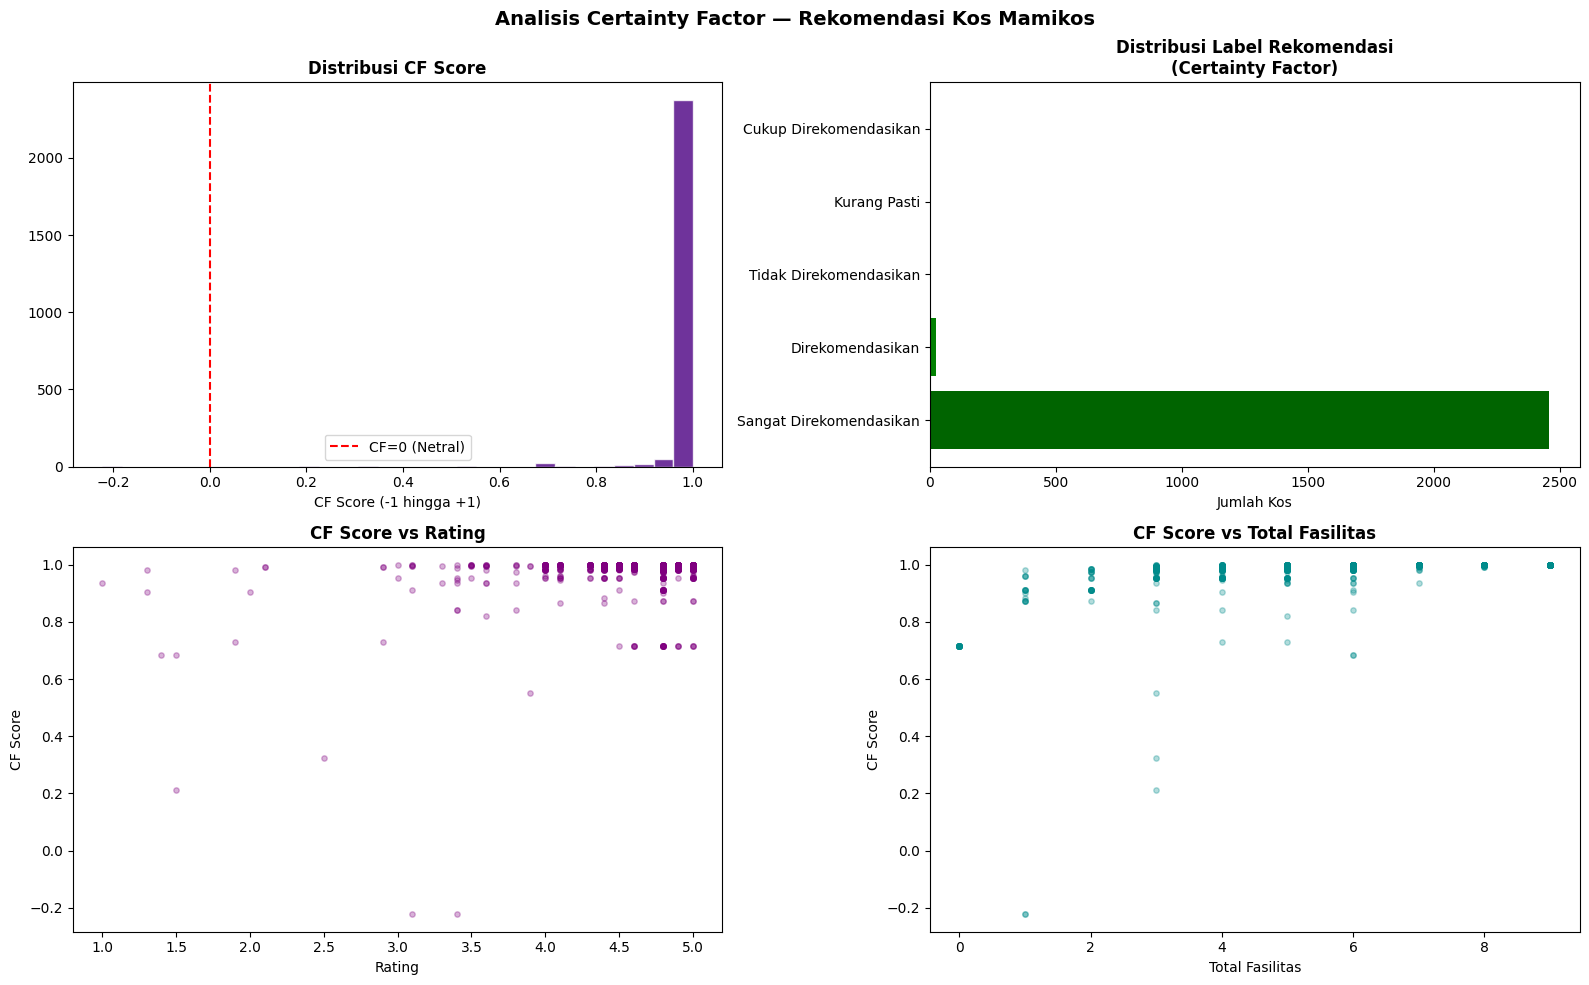

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Distribusi CF Score
axes[0,0].hist(df['cf_score'], bins=30, color='indigo', edgecolor='white', alpha=0.8)
axes[0,0].axvline(0, color='red', linestyle='--', label='CF=0 (Netral)')
axes[0,0].set_title('Distribusi CF Score', fontweight='bold')
axes[0,0].set_xlabel('CF Score (-1 hingga +1)')
axes[0,0].legend()

# Plot 2: Distribusi Label CF
label_counts = df['cf_label'].value_counts()
colors = ['darkgreen','green','limegreen','gold','gray','red']
axes[0,1].barh(label_counts.index, label_counts.values, color=colors[:len(label_counts)])
axes[0,1].set_title('Distribusi Label Rekomendasi\n(Certainty Factor)', fontweight='bold')
axes[0,1].set_xlabel('Jumlah Kos')

# Plot 3: CF Score vs Rating
axes[1,0].scatter(df['rating_numeric'], df['cf_score'], alpha=0.3, c='purple', s=15)
axes[1,0].set_title('CF Score vs Rating', fontweight='bold')
axes[1,0].set_xlabel('Rating')
axes[1,0].set_ylabel('CF Score')

# Plot 4: CF Score vs Jumlah Fasilitas
axes[1,1].scatter(df['total_facilities'], df['cf_score'], alpha=0.3, c='darkcyan', s=15)
axes[1,1].set_title('CF Score vs Total Fasilitas', fontweight='bold')
axes[1,1].set_xlabel('Total Fasilitas')
axes[1,1].set_ylabel('CF Score')

plt.suptitle('Analisis Certainty Factor — Rekomendasi Kos Mamikos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('certainty_factor_result.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 10 Kos dengan CF Tertinggi

In [ ]:
print('=== TOP 10 KOS — CF SCORE TERTINGGI ===')
top10_cf = df.nlargest(10, 'cf_score')[[
    'room_name', 'region', 'tipe_kos', 'price_numeric',
    'rating_numeric', 'total_facilities', 'cf_score', 'cf_label'
]]
print(top10_cf.to_string())
print()

print('=== STATISTIK CF PER LABEL ===')
print(df.groupby('cf_label')['cf_score'].agg(['mean', 'min', 'max', 'count']).round(4))

=== TOP 10 KOS — CF SCORE TERTINGGI ===
                                                                          room_name           region    tipe_kos  price_numeric  rating_numeric  total_facilities  cf_score                 cf_label
10                      Kost 3tranches Home Senopati Kebayoran Baru Jakarta Selatan  Jakarta Selatan  Kos Campur        3800000             4.6                 8  0.999947  Sangat Direkomendasikan
971               Kost Joyo Signature Deluxe Twin Suite Cempaka Putih Jakarta Pusat    Jakarta Pusat  Kos Campur        4000000             4.8                 8  0.999947  Sangat Direkomendasikan
972               Kost Joyo Signature Deluxe Twin Suite Cempaka Putih Jakarta Pusat    Jakarta Pusat  Kos Campur        4000000             4.8                 7  0.999947  Sangat Direkomendasikan
973                   Kost Joyo Signature Premier Suite Cempaka Putih Jakarta Pusat    Jakarta Pusat  Kos Campur        4500000             4.8                 8  0.999947 

### Ringkasan & Analisis Certainty Factor

In [ ]:
print('=' * 65)
print('RINGKASAN CERTAINTY FACTOR')
print('=' * 65)
print(f'Total data kos         : {len(df)}')
print(f'Total CF Rules         : {len(CF_RULES)}')
print(f'  Rules positif        : {len([r for r in CF_RULES if r["CF_pakar"] > 0])}')
print(f'  Rules negatif        : {len([r for r in CF_RULES if r["CF_pakar"] < 0])}')
print(f'Rata-rata CF Score     : {df["cf_score"].mean():.4f}')
print(f'Kos CF >= 0.6 (Direk.) : {(df["cf_score"] >= 0.6).sum()} ({(df["cf_score"] >= 0.6).mean()*100:.1f}%)')
print(f'Kos CF < 0 (Tidak Rek.): {(df["cf_score"] < 0).sum()} ({(df["cf_score"] < 0).mean()*100:.1f}%)')
print()
print('Rumus CF Kombinasi yang Digunakan:')
print('  Positif + Positif : CF1 + CF2 × (1 - CF1)')
print('  Negatif + Negatif : CF1 + CF2 × (1 + CF1)')
print('  Berbeda tanda     : (CF1 + CF2) / (1 - min(|CF1|, |CF2|))')
print('  User + Expert     : CF_final = CF_user × CF_pakar')
print()
print('Kelebihan Certainty Factor:')
print('  - Merepresentasikan keyakinan pakar secara eksplisit')
print('  - Mendukung aturan dengan tingkat kepercayaan berbeda')
print('  - Bisa menangani evidence positif DAN negatif dalam satu framework')
print('  - CF_user memungkinkan personalisasi tingkat keyakinan pengguna')
print()
print('Keterbatasan Certainty Factor:')
print('  - CF_pakar harus ditentukan secara manual oleh domain expert')
print('  - Kombinasi CF tidak sepenuhnya konsisten secara probabilistik')
print('  - Tidak ada mekanisme pembelajaran otomatis dari data')

RINGKASAN CERTAINTY FACTOR
Total data kos         : 2485
Total CF Rules         : 13
  Rules positif        : 10
  Rules negatif        : 3
Rata-rata CF Score     : 0.9899
Kos CF >= 0.6 (Direk.) : 2480 (99.8%)
Kos CF < 0 (Tidak Rek.): 2 (0.1%)

Rumus CF Kombinasi yang Digunakan:
  Positif + Positif : CF1 + CF2 × (1 - CF1)
  Negatif + Negatif : CF1 + CF2 × (1 + CF1)
  Berbeda tanda     : (CF1 + CF2) / (1 - min(|CF1|, |CF2|))
  User + Expert     : CF_final = CF_user × CF_pakar

Kelebihan Certainty Factor:
  - Merepresentasikan keyakinan pakar secara eksplisit
  - Mendukung aturan dengan tingkat kepercayaan berbeda
  - Bisa menangani evidence positif DAN negatif dalam satu framework
  - CF_user memungkinkan personalisasi tingkat keyakinan pengguna

Keterbatasan Certainty Factor:
  - CF_pakar harus ditentukan secara manual oleh domain expert
  - Kombinasi CF tidak sepenuhnya konsisten secara probabilistik
  - Tidak ada mekanisme pembelajaran otomatis dari data
